# 13. Classification II: Support Vector Machine
@Shengli (Bruce) Jiang, University of South Carolina


## What We Have Covered

- Python, NumPy, pandas, functions, and plotting
- Training, validation, and test data
- Scaling and preprocessing pipelines
- Linear and nonlinear regression
- Logistic regression and class probabilities
- Confusion matrices and classification metrics
- One-vs-rest and one-vs-one multiclass classification

## What We Covered in the Last Lecture

Logistic regression starts with a linear score and converts it to a probability with the
sigmoid function. A threshold then gives the predicted class.

For multiclass problems, we used two common strategies:

- **One-vs-rest:** one classifier for each class against all remaining classes.
- **One-vs-one:** one classifier for each pair of classes.

Today we keep the classification problem, but change how the decision boundary is learned.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the decision boundary, margin, and support vectors in a linear SVM.
2. Explain why SVM tries to maximize the margin.
3. Describe how the soft-margin parameter `C` changes the penalty for violations.
4. Use scaling and a pipeline before fitting an SVM.
5. Train and evaluate a multiclass linear SVM with `SVC`.
6. Explain the basic idea of feature mapping and the kernel trick.

We will keep the coding example linear. The kernel section is only to connect the math idea to the lecture slides.

## Running the Notebook

The Wine recognition dataset is included with scikit-learn, so no download is required.
Run the cells from top to bottom.

We use only **alcohol** and **color intensity** as inputs. Two features are not enough for the
best possible wine classifier, but they let us draw the decision boundaries and support vectors.

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()

cultivar_names = {
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2"
}

features = ["alcohol", "color_intensity"]
X = wine_df[features]
y = wine_df["target"]

print("Samples:", len(wine_df))
print("Classes:", [int(value) for value in sorted(y.unique())])

Samples: 178
Classes: [0, 1, 2]


## 1. Start with the Three-Class Wine Problem

The same two measurements from Lecture 12 are used again. The classes overlap, so no single
straight line can separate all three classes at once.

Before SVM, recall the multiclass idea: a binary classifier can be reused through
one-vs-rest or one-vs-one.

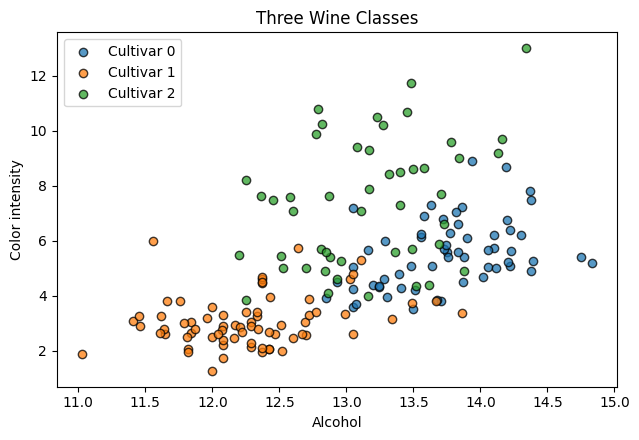

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for label, color in [(0, "C0"), (1, "C1"), (2, "C2")]:
    selected = y == label
    ax.scatter(
        X.loc[selected, "alcohol"],
        X.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=cultivar_names[label]
    )

ax.set(xlabel="Alcohol", ylabel="Color intensity", title="Three Wine Classes")
ax.legend()
fig.tight_layout()
plt.show()

### Quick multiclass recap

With three classes:

- One-vs-rest trains 3 binary classifiers.
- One-vs-one also trains 3 binary classifiers: 0 vs 1, 0 vs 2, and 1 vs 2.

For four classes the counts become different: 4 classifiers for OvR and 6 for OvO.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=26, stratify=y
)

multiclass_models = {
    "One-vs-rest": OneVsRestClassifier(LogisticRegression(max_iter=2000)),
    "One-vs-one": OneVsOneClassifier(LogisticRegression(max_iter=2000))
}

recap_rows = []

for name, classifier in multiclass_models.items():
    model = Pipeline([("scaler", StandardScaler()), ("classifier", classifier)])
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    n_classifiers = len(model.named_steps["classifier"].estimators_)
    recap_rows.append({
        "Strategy": name,
        "Binary classifiers": n_classifiers,
        "Test accuracy": accuracy_score(y_test, prediction)
    })

display(pd.DataFrame(recap_rows).round(3))

,Strategy,Binary classifiers,Test accuracy
0,One-vs-rest,3,0.889
1,One-vs-one,3,0.889


## 2. Binary SVM First: Where Should the Boundary Go?

The geometry is easiest to see with two classes, so first keep only Cultivar 0 and Cultivar 1.

A linear classifier uses

$$
f(\mathbf{x}) = \mathbf{w}^{T}\mathbf{x} + b.
$$

The decision boundary is where $f(\mathbf{x})=0$.

Many lines may classify the training points reasonably well. SVM prefers a boundary with a
large margin around it.

In [ ]:
binary_mask = y.isin([0, 1])
X_binary = X.loc[binary_mask]
y_binary = y.loc[binary_mask]

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary, y_binary, test_size=0.20, random_state=26, stratify=y_binary
)

binary_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1))
])

binary_svm.fit(X_binary_train, y_binary_train)

print("Training accuracy:", round(binary_svm.score(X_binary_train, y_binary_train), 3))
print("Test accuracy:", round(binary_svm.score(X_binary_test, y_binary_test), 3))

Training accuracy: 0.904
Test accuracy: 0.962


### Why do we scale first?

The SVM margin is based on distances in feature space. If one feature has a much larger
numerical scale, it can dominate those distances.

`StandardScaler` puts the two features on comparable scales. The pipeline also makes sure
the scaler is fitted only on the training data.

## 3. Margin and Support Vectors

For a fitted binary SVM, scikit-learn scales the decision function so that the two margin
boundaries occur at

$$
f(\mathbf{x})=-1 \quad \text{and} \quad f(\mathbf{x})=+1.
$$

The training points on or inside these margins are the **support vectors**.

The full margin width is the distance between the two margin boundaries. The distance from
the center decision boundary to either margin boundary is half of that width.

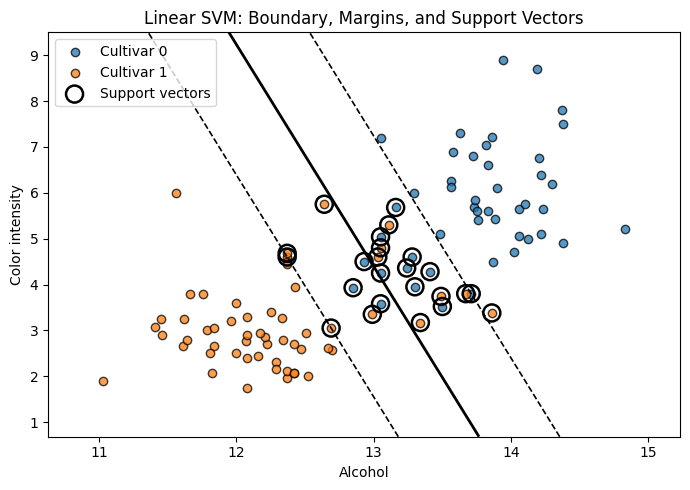

Training samples: 104
Support vectors: 24


In [ ]:
x_min, x_max = X_binary["alcohol"].min() - 0.4, X_binary["alcohol"].max() + 0.4
y_min = X_binary["color_intensity"].min() - 0.6
y_max = X_binary["color_intensity"].max() + 0.6

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

grid = pd.DataFrame({"alcohol": xx.ravel(), "color_intensity": yy.ravel()})
decision = binary_svm.decision_function(grid).reshape(xx.shape)

scaler = binary_svm.named_steps["scaler"]
svm = binary_svm.named_steps["svm"]
support_vectors = scaler.inverse_transform(svm.support_vectors_)

fig, ax = plt.subplots(figsize=(7, 5))

for label, color in [(0, "C0"), (1, "C1")]:
    selected = y_binary_train == label
    ax.scatter(
        X_binary_train.loc[selected, "alcohol"],
        X_binary_train.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=cultivar_names[label]
    )

ax.contour(xx, yy, decision, levels=[-1, 0, 1], colors="black",
           linestyles=["--", "-", "--"], linewidths=[1.2, 2.0, 1.2])

ax.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    label="Support vectors"
)

ax.set(xlabel="Alcohol", ylabel="Color intensity",
       title="Linear SVM: Boundary, Margins, and Support Vectors")
ax.legend()
fig.tight_layout()
plt.show()

print("Training samples:", len(X_binary_train))
print("Support vectors:", len(support_vectors))

## 4. Soft Margin and the Parameter C

Real data overlap. Requiring perfect separation can be too strict.

A soft-margin SVM balances two goals:

- keep the margin wide;
- penalize points that enter the margin or fall on the wrong side.

`C` controls how strongly those violations are penalized.

- **Smaller C:** weaker penalty for violations, stronger regularization.
- **Larger C:** stronger penalty for violations, weaker regularization.

A larger `C` often gives a narrower margin and fewer training violations, but this is a
tradeoff, not a guarantee for every dataset.

In [ ]:
c_values = [0.03, 1, 100]
c_rows = []

for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=c_value))
    ])
    model.fit(X_binary_train, y_binary_train)

    c_rows.append({
        "C": c_value,
        "Training accuracy": model.score(X_binary_train, y_binary_train),
        "Test accuracy": model.score(X_binary_test, y_binary_test),
        "Support vectors": len(model.named_steps["svm"].support_)
    })

display(pd.DataFrame(c_rows).round(3))

,C,Training accuracy,Test accuracy,Support vectors
0,0.03,0.904,0.962,52
1,1.00,0.904,0.962,24
2,100.00,0.913,1.000,22


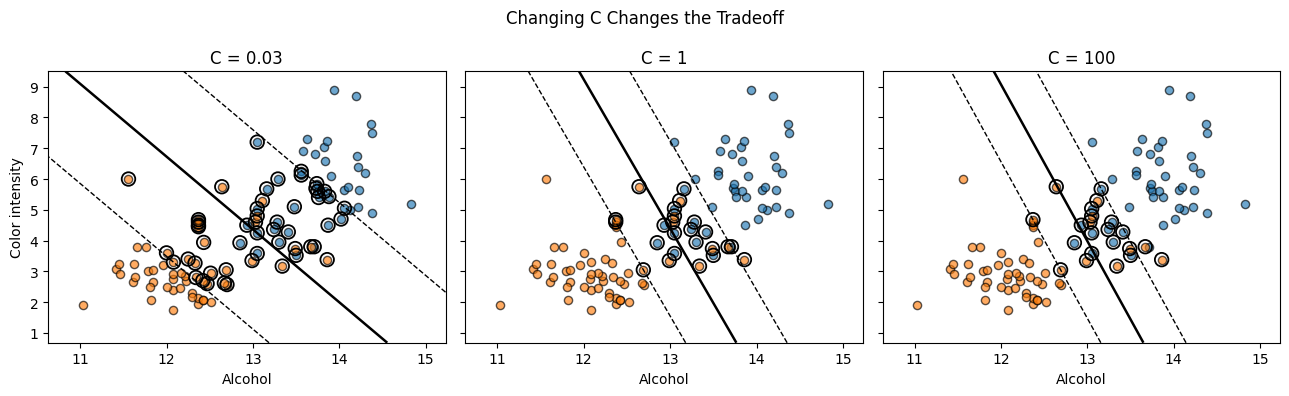

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

for ax, c_value in zip(axes, c_values):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=c_value))
    ])
    model.fit(X_binary_train, y_binary_train)

    decision = model.decision_function(grid).reshape(xx.shape)
    scaler = model.named_steps["scaler"]
    svm = model.named_steps["svm"]
    support_vectors = scaler.inverse_transform(svm.support_vectors_)

    for label, color in [(0, "C0"), (1, "C1")]:
        selected = y_binary_train == label
        ax.scatter(
            X_binary_train.loc[selected, "alcohol"],
            X_binary_train.loc[selected, "color_intensity"],
            color=color,
            edgecolor="black",
            alpha=0.65,
            s=35
        )

    ax.contour(xx, yy, decision, levels=[-1, 0, 1], colors="black",
               linestyles=["--", "-", "--"], linewidths=[1, 1.8, 1])
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=95,
               facecolors="none", edgecolors="black", linewidths=1.3)

    ax.set_title("C = " + str(c_value))
    ax.set_xlabel("Alcohol")

axes[0].set_ylabel("Color intensity")
fig.suptitle("Changing C Changes the Tradeoff")
fig.tight_layout()
plt.show()

## 5. Back to Three Classes: Multiclass SVC

Now use all three cultivars.

`SVC` handles multiclass classification internally with a **one-vs-one** strategy. With
three classes, it fits three pairwise SVMs.

One scikit-learn detail can look confusing: the default
`decision_function_shape="ovr"` changes the shape of the scores returned by
`decision_function`. It does **not** change the internal SVC training strategy from
one-vs-one to one-vs-rest.

In [ ]:
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1))
])

svm_linear.fit(X_train, y_train)
y_pred = svm_linear.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Support vectors by class:", svm_linear.named_steps["svm"].n_support_)
print("Total support vectors:", len(svm_linear.named_steps["svm"].support_))

Test accuracy: 0.889
Support vectors by class: [24 16 23]
Total support vectors: 63


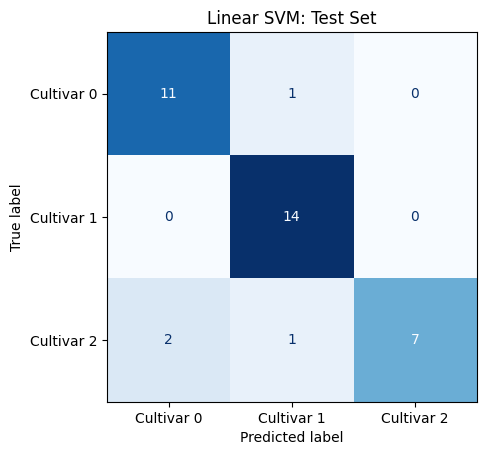

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[cultivar_names[i] for i in range(3)],
    cmap="Blues",
    colorbar=False
)
plt.title("Linear SVM: Test Set")
plt.show()

### Read the confusion matrix

Do not stop at the overall accuracy.

- Which cultivar is easiest for this two-feature model?
- Which cultivar is confused most often with another class?
- Would you expect the result to improve if all 13 wine features were used?

The goal here is not to build the best wine classifier. The two-feature model keeps the SVM
geometry visible.

## 6. Multiclass Decision Regions and Support Vectors

Each colored region below shows the class predicted for a new point at that location.

The circled training samples are support vectors used by the pairwise SVMs. In a multiclass
SVC, the final picture combines several pairwise linear decisions.

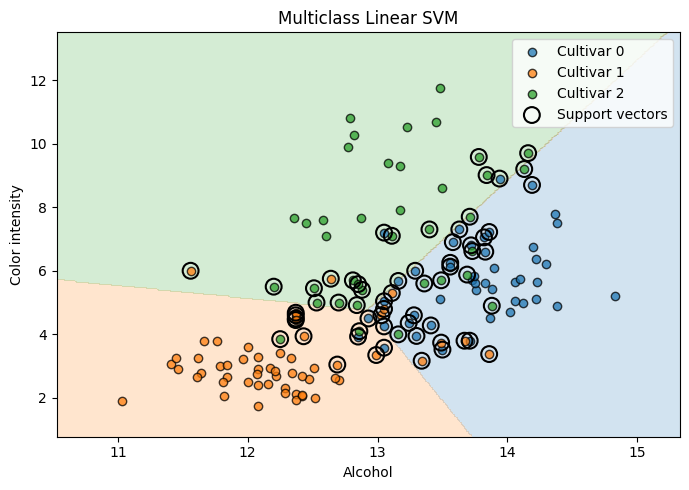

In [ ]:
x_min, x_max = X["alcohol"].min() - 0.5, X["alcohol"].max() + 0.5
y_min, y_max = X["color_intensity"].min() - 0.5, X["color_intensity"].max() + 0.5

xx_multi, yy_multi = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

grid_multi = pd.DataFrame({
    "alcohol": xx_multi.ravel(),
    "color_intensity": yy_multi.ravel()
})

predicted_region = svm_linear.predict(grid_multi).reshape(xx_multi.shape)

scaler = svm_linear.named_steps["scaler"]
svm = svm_linear.named_steps["svm"]
support_vectors = scaler.inverse_transform(svm.support_vectors_)

fig, ax = plt.subplots(figsize=(7, 5))

ax.contourf(
    xx_multi,
    yy_multi,
    predicted_region,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=["C0", "C1", "C2"],
    alpha=0.20
)

for label, color in [(0, "C0"), (1, "C1"), (2, "C2")]:
    selected = y_train == label
    ax.scatter(
        X_train.loc[selected, "alcohol"],
        X_train.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=cultivar_names[label]
    )

ax.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=130,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support vectors"
)

ax.set(xlabel="Alcohol", ylabel="Color intensity",
       title="Multiclass Linear SVM")
ax.legend()
fig.tight_layout()
plt.show()

### A new wine sample

Prediction is now simple from the user's point of view. The pairwise work happens inside
`SVC`.

Change the two measurements below and rerun the cell. Watch where the sample would fall on
the decision-region plot.

In [ ]:
new_wine = pd.DataFrame({"alcohol": [13.2], "color_intensity": [5.0]})

new_class = svm_linear.predict(new_wine)[0]
scores = svm_linear.decision_function(new_wine)[0]

print("Predicted class:", cultivar_names[new_class])
display(pd.DataFrame({
    "Class": [cultivar_names[i] for i in range(3)],
    "Decision score": scores
}).round(3))

Predicted class: Cultivar 0


,Class,Decision score
0,Cultivar 0,2.171
1,Cultivar 1,-0.157
2,Cultivar 2,0.953


## 7. Feature Mapping and the Kernel Trick

The lecture slides ask what happens when a straight boundary is not enough.

One idea is to map the original inputs into new features, then fit a linear boundary in that
new feature space. The problem is that the new feature vector can become very large.

Kernel SVMs use a useful shortcut: the optimization can be written using dot products
between transformed samples. A kernel computes that dot product without explicitly building
all transformed coordinates.

We are **not fitting a nonlinear SVM here**. The small calculation below only shows the
kernel-trick identity.

In [ ]:
x_a = np.array([1.0, 2.0])
x_b = np.array([2.0, 1.0])

phi_a = np.array([
    x_a[0] ** 2,
    np.sqrt(2) * x_a[0] * x_a[1],
    x_a[1] ** 2
])

phi_b = np.array([
    x_b[0] ** 2,
    np.sqrt(2) * x_b[0] * x_b[1],
    x_b[1] ** 2
])

explicit_dot = phi_a @ phi_b
kernel_dot = (x_a @ x_b) ** 2

print("Dot product after explicit feature mapping:", explicit_dot)
print("Same value from the polynomial kernel:", kernel_dot)

Dot product after explicit feature mapping: 16.0
Same value from the polynomial kernel: 16.0


The two numbers are the same:

$$
\phi(\mathbf{x}_a)^T\phi(\mathbf{x}_b)
=
(\mathbf{x}_a^T\mathbf{x}_b)^2.
$$

For this small example, explicitly building `phi` is easy. The kernel trick matters when the
transformed feature space is very large or even infinite-dimensional.